In [3]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itables import init_notebook_mode, show

# Eigene robusten Parquet-Helper
from utils.parquet_io import load_parquet

init_notebook_mode(all_interactive=True)
# Projekt-Root bestimmen (2 Ebenen über notebooks/)
ROOT = Path.cwd().parents[0]   # oder ggf. .parents[1], je nachdem wo dein notebooks/ liegt
DATA_DIR = ROOT / "data"

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
def load_and_info(path: Path) -> pd.DataFrame:
    """Lädt ein Parquet und gibt Infos aus."""
    df = load_parquet(path)
    print(f"\n--- {path.name} ---")
    print(f"Shape: {df.shape}")
    print(f"Columns: {len(df.columns)}")
    return df

ROOT: C:\Dev\Bachelorarbeit
DATA_DIR: C:\Dev\Bachelorarbeit\data


In [29]:
raw_dir = DATA_DIR / "raw" / "assets_regions"

df_btc = load_and_info(raw_dir / "BTC-USD.parquet")
display(df_btc.head(), df_btc.tail())

df_spy = load_and_info(raw_dir / "SPY.parquet")
display(df_spy.head(), df_spy.tail())


--- BTC-USD.parquet ---
Shape: (3865, 8)
Columns: 8


,date,open,high,low,close,volume,volumeNotional,tradesDone
0,2014-06-01T00:00:00+00:00,621.00,628.50,611.00,627.80,9696.71,6.087595e+06,0.0
1,2014-06-02T00:00:00+00:00,627.80,683.26,618.53,630.99,24149.98,1.523840e+07,0.0
2,2014-06-03T00:00:00+00:00,630.99,678.00,613.03,661.22,20087.28,1.328211e+07,0.0
3,2014-06-04T00:00:00+00:00,662.00,680.99,649.61,670.14,13572.81,9.095683e+06,0.0
4,2014-06-05T00:00:00+00:00,668.90,673.61,621.86,640.59,17375.57,1.113062e+07,0.0


,date,open,high,low,close,volume,volumeNotional,tradesDone
3860,2024-12-28T00:00:00+00:00,94185.035310,95557.388043,94030.431040,95163.632624,4248.139276,4.042684e+08,454540.0
3861,2024-12-29T00:00:00+00:00,95172.839996,95206.884230,92884.741082,93603.088025,5410.327008,5.064233e+08,457803.0
3862,2024-12-30T00:00:00+00:00,93596.204244,94926.586665,91312.413450,92656.240425,20819.468761,1.929054e+09,774207.0
3863,2024-12-31T00:00:00+00:00,92650.418961,96161.032971,91911.081744,93390.555466,14572.349802,1.360920e+09,688046.0
3864,2025-01-01T00:00:00+00:00,93376.269836,94977.830995,92765.302188,94407.764230,8931.655782,8.432177e+08,457051.0



--- SPY.parquet ---
Shape: (2665, 13)
Columns: 13


,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,2014-06-02T00:00:00.000Z,192.90,192.99,191.97,192.95,64655648,158.575794,158.649779,157.811276,158.616897,64655648,0.0,1.0
1,2014-06-03T00:00:00.000Z,192.80,192.90,192.25,192.43,65047193,158.493587,158.575794,158.041453,158.189424,65047193,0.0,1.0
2,2014-06-04T00:00:00.000Z,193.19,193.30,192.27,192.47,55529372,158.814192,158.904619,158.057895,158.222307,55529372,0.0,1.0
3,2014-06-05T00:00:00.000Z,194.45,194.65,192.70,193.41,92102592,159.849990,160.014403,158.411381,158.995045,92102592,0.0,1.0
4,2014-06-06T00:00:00.000Z,195.38,195.43,194.78,194.87,78696219,160.614508,160.655611,160.121271,160.195256,78696219,0.0,1.0


,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
2660,2024-12-24T00:00:00.000Z,601.30,601.3400,595.4700,596.060,33160097,597.726363,597.766125,591.931012,592.517505,33160097,0.0,1.0
2661,2024-12-26T00:00:00.000Z,601.34,602.4800,598.0825,599.500,41338891,597.766125,598.899350,594.527985,595.937061,41338891,0.0,1.0
2662,2024-12-27T00:00:00.000Z,595.01,597.7761,590.7647,597.540,64969310,591.473745,594.223406,587.253676,593.988709,64969310,0.0,1.0
2663,2024-12-30T00:00:00.000Z,588.22,591.7400,584.4100,587.890,56578757,584.724100,588.223180,580.936743,584.396061,56578757,0.0,1.0
2664,2024-12-31T00:00:00.000Z,586.08,590.6399,584.4200,589.905,57052654,582.596818,587.129618,580.946684,586.399085,57052654,0.0,1.0


In [9]:
df_interim = load_and_info(DATA_DIR / "interim" / "panel.parquet")
display(df_interim.head(), df_interim.tail())

# Beispiel: alle Spalten
print(df_interim.columns.tolist()[:10], "...")

# Nach Datum & Asset filtern
sample_date = str(df_interim.index.get_level_values("date")[0].date())
df_interim_date = df_interim.xs("BTC-USD", level="asset").loc["2015-01-01":"2015-01-21"]
display(df_interim_date)



--- panel.parquet ---
Shape: (21320, 8)
Columns: 8


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


['open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividends', 'stock_splits'] ...


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)



--- features_v1.parquet ---
Shape: (21320, 30)
Columns: 30


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


['open', 'high', 'low', 'close', 'adj_open', 'adj_close', 'volume', 'dividends', 'stock_splits', 'daily_return_log', 'average_dollar_volume_20', 'volatility_becker_parkinson', 'bid_ask_spread_corwin_schultz', 'simple_moving_average_20', 'simple_moving_average_60'] ...


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


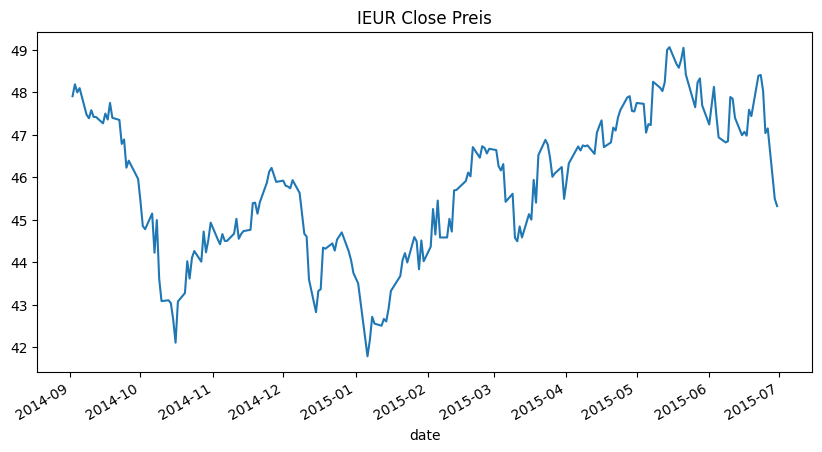

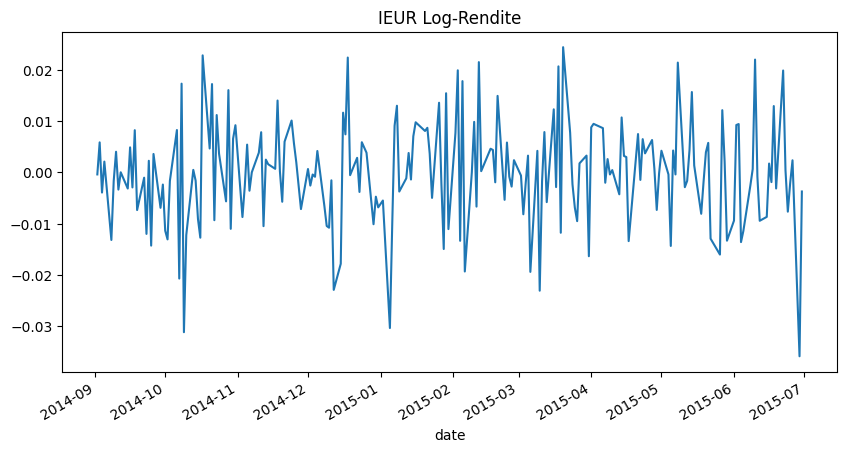

In [36]:
df_clean = load_and_info(DATA_DIR / "clean" / "features_v1.parquet")
display(df_clean.head(30), df_clean.tail())
# Spaltenliste
print(df_clean.columns.tolist()[:15], "...")

# Ein Asset über Zeitraum herausfiltern
asset = "IEUR"
date_range = slice("2014-09-01", "2015-06-30")
df_clean_asset = df_clean.xs(asset, level="asset").loc[date_range]
display(df_clean_asset.head(30))

# Plot Close Preis
df_clean_asset["close"].plot(title=f"{asset} Close Preis", figsize=(10,5))
plt.show()

# Plot Log-Renditen
df_clean_asset["daily_return_log"].plot(title=f"{asset} Log-Rendite", figsize=(10,5))
plt.show()



In [27]:
df_rf = load_and_info(DATA_DIR / "clean" / "riskfree_norm.parquet")
display(df_rf.head(100), df_rf.tail())


--- riskfree_norm.parquet ---
Shape: (2665, 3)
Columns: 3


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)



--- portfolio_snapshots.parquet ---
Shape: (88, 9)
Columns: 9


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)



--- trade_events.parquet ---
Shape: (57, 11)
Columns: 11


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)



--- rewards_log.parquet ---
Shape: (10, 18)
Columns: 18


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


<Axes: title={'center': 'Rewards pro Round'}, xlabel='round'>

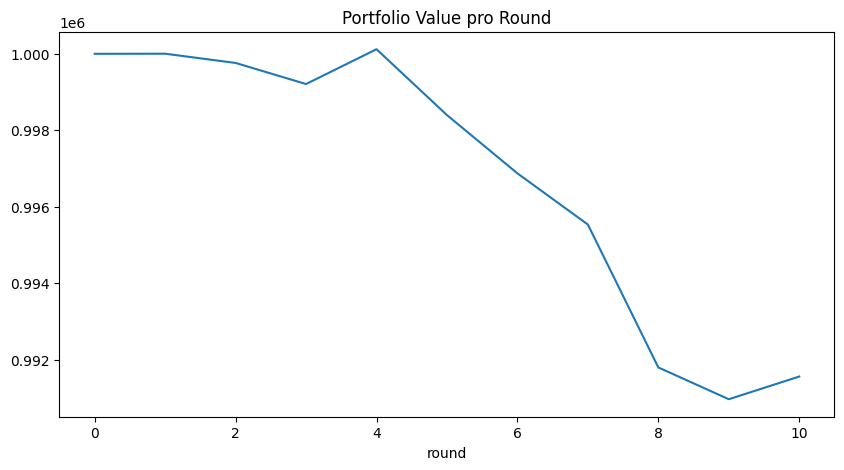

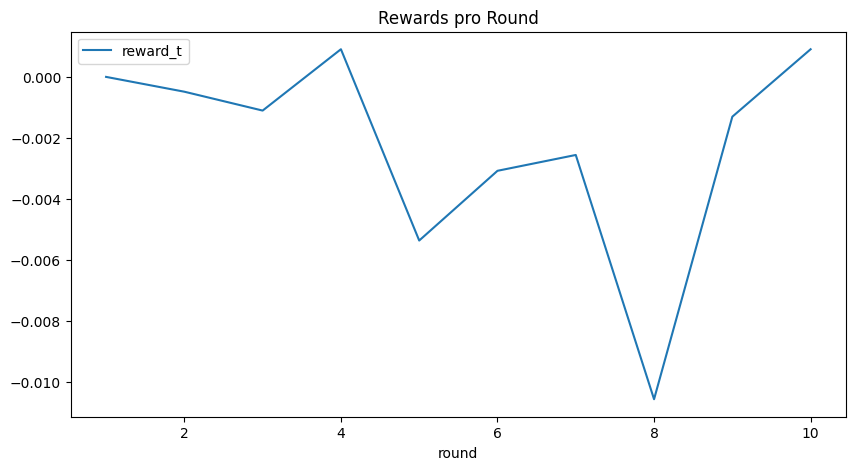

In [40]:
acc_demo = DATA_DIR / "accounting_demo"

df_snap = load_and_info(acc_demo / "portfolio_snapshots.parquet")
display(df_snap.head(80), df_snap.tail(20))

df_trades = load_and_info(acc_demo / "trade_events.parquet")
display(df_trades.head(12), df_trades.tail(10))

df_rewards = load_and_info(acc_demo / "rewards_log.parquet")
display(df_rewards.head(20), df_rewards.tail(20))

# Plot Portfolio Value Verlauf
df_snap.groupby("round")["portfolio_value_t"].mean().plot(
    title="Portfolio Value pro Round", figsize=(10,5))
#plt.show()

# Plot Rewards Verlauf
df_rewards.plot(x="round", y="reward_t", title="Rewards pro Round", figsize=(10,5))
#plt.show()

In [117]:
df_2015_01_02 = df_clean.xs("2015-01-02", level="date")
df_2015_01_02.loc["SPY"].filter(like="moving_average")

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [31]:
df_state = load_and_info(DATA_DIR / "states" / "states_demo" / "state_weights.parquet")
display(df_state.head(9), df_state.tail())


--- state_weights.parquet ---
Shape: (8, 4)
Columns: 4


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [83]:
df_state = load_and_info(DATA_DIR / "cpcv" / "years" / "features" / "2019.parquet")
display(df_state.head(), df_state.tail(10))


--- 2019.parquet ---
Shape: (2016, 29)
Columns: 29


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)
